In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Supply Chain Network Design with Linear Programming

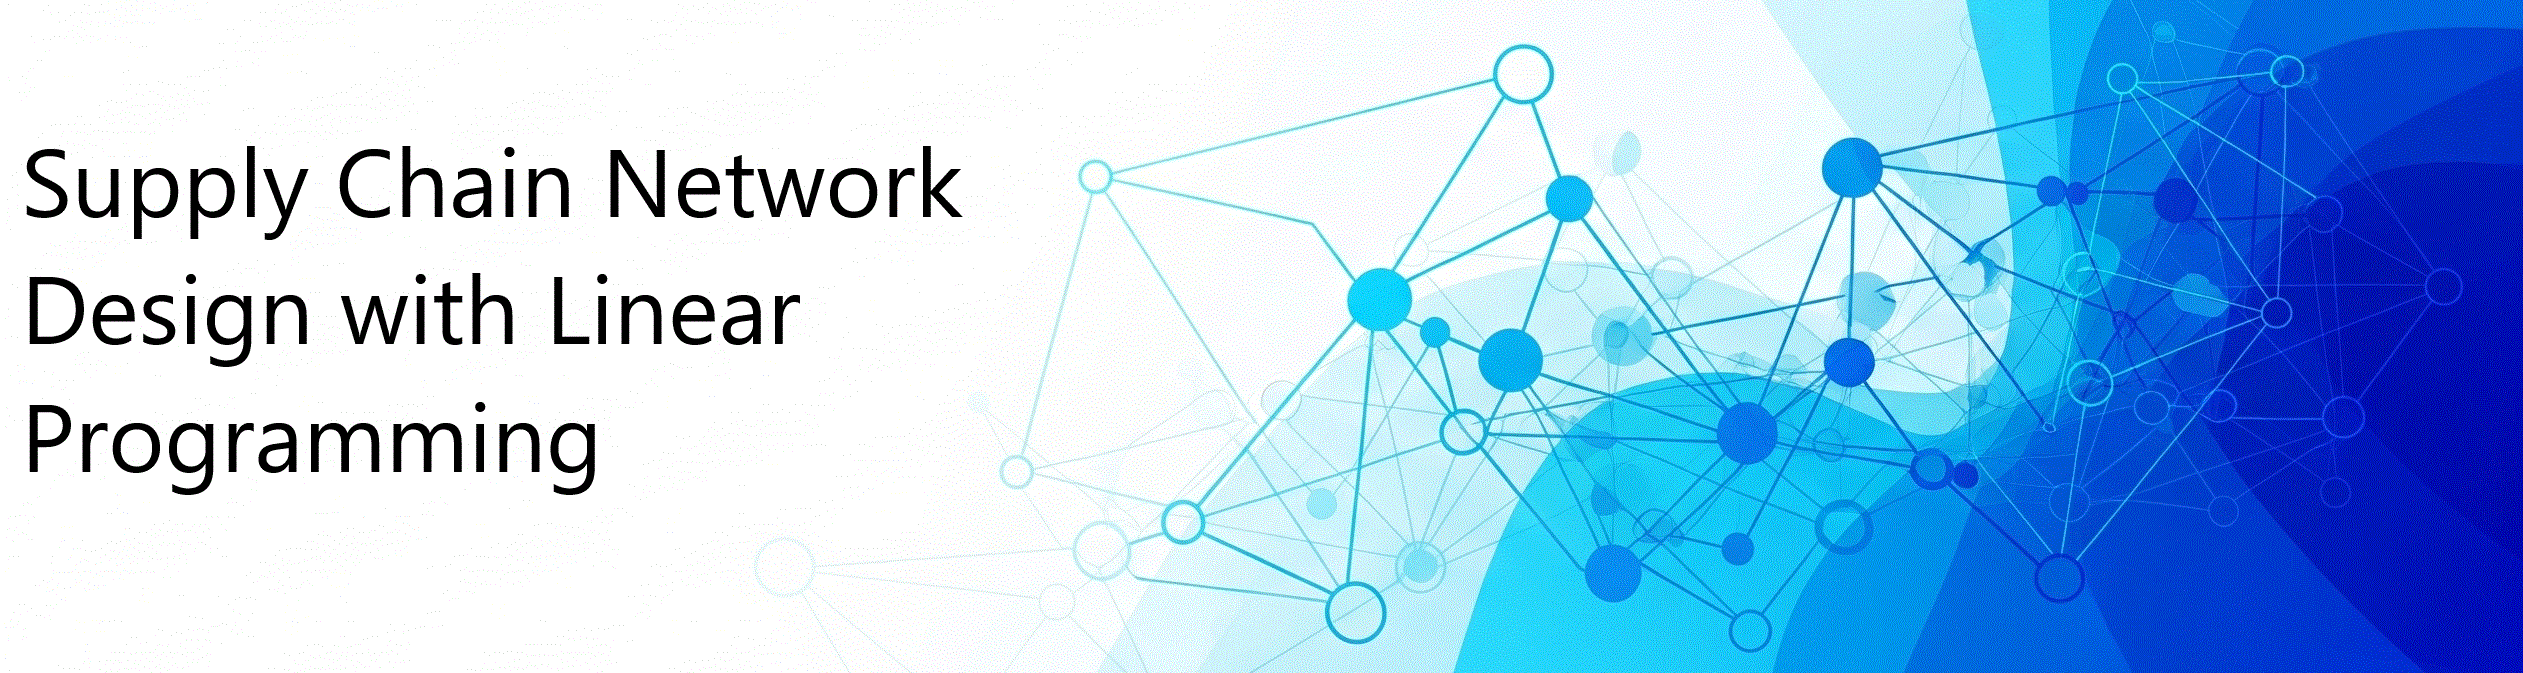

# Introduction

Having recently delved into the fascinating world of **linear programming** in Python, I wanted to create a practical, hands-on example that not only solidifies my understanding but also serves as a valuable learning resource for other professionals approaching this powerful optimization technique. This article is designed as a test case, demonstrating how linear programming can be applied for supply chain network design.

For businesses, getting products from suppliers to customers efficiently and cost-effectively is paramount. One of the most fundamental strategic decisions in supply chain management is Supply Chain Network Design. This involves figuring out the optimal locations for your facilities, like warehouses, distribution centers, and factories.

Let's take an example where you're managing a growing company. Do you open one big warehouse, or several smaller ones? Where should they be located? How will they serve your customers most effectively and efficiently? These are the kinds of complex questions that Geographic Optimization can help answer.

This article will walk you through how we can use Python and a little bit of "smart math" (what we call optimization) to make these strategic location decisions. We'll simulate a simplified scenario and show how to find the best places for your distribution centers to serve customers efficiently.

It's important to note that this is an approach that needs to be explored and learned as first step in this field. Afterward, it will be necessary to understand and implement solutions that are much closer to real-world situations, which therefore involve repeated decisions over time whenever one of the variables in play changes. Always remembering to incorporate the uncertainty and variability that govern many systems today. Fortunately, there is a growing literature on the subject.


# The Problem: Where to Put Our Warehouses?

The challenge we're addressing is a classic problem known as the **Facility Location Problem**. We want to determine which new distribution centers (DCs) to open from a set of potential locations to best serve our customers. The goal is to minimize the total cost, which typically includes two main components:

* **Fixed Costs**: The cost of opening and operating a distribution center, regardless of how much product it handles (e.g., rent, utilities, initial setup).

* **Variable Costs**: The cost of shipping products from a DC to customers, which depends on the distance and volume.

**We need to decide**:

1.  Which potential distribution center locations should we choose to open?

2.  Once opened, which customers should each distribution center serve?

Opening more warehouses might reduce shipping costs (because they're closer to customers), but it increases fixed costs. Conversely, fewer warehouses mean lower fixed costs but potentially higher shipping costs. **Our optimization model will find the sweet spot!**

# Our Approach: Data-Driven Decisions with Optimization

To solve this, we'll follow a data-driven approach. We'll define:

1. Customer Locations and Demand: Where our customers are, and how much product they need.

2. Potential Distribution Center Locations: A list of places where we could open a warehouse.

3. Costs: The fixed cost of opening each potential warehouse and the variable cost of shipping goods from each warehouse to each customer.

We'll use a technique called Linear Programming. 
**Linear Programming** is a way to find the absolute best solution (like the lowest cost or highest profit) when everything you're dealing with can be described with straight lines and simple relationships. It's incredibly powerful for making decisions when you have many choices and constraints.

In the following code we will import the libraries we will use.

In [2]:
import pandas as pd
import numpy as np
import random
from math import radians, sin, cos, sqrt, atan2

import matplotlib.pyplot as plt
import folium # For interactive mapping

!pip install pulp
import pulp # Import the PuLP library for Linear Programming

# Simulating Our Supply Chain Data

### haversine_distance function: 

This is a simple formula to calculate the approximate straight-line distance between two points on Earth using their latitude and longitude. This is how we'll estimate shipping distances and, therefore, shipping costs.

In [3]:
# Function to calculate approximate distance between two lat/lon points (Haversine formula)
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the distance between two points on Earth using the Haversine formula.
    This gives us a reasonable approximation for transportation costs based on distance.
    """
    R = 6371  # Radius of Earth in kilometers

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance

### Customer Data: 

We now create **50** imaginary customer locations with random latitude and longitude coordinates centered around Milan, Italy.

Each customer also has a demand, the amount of product they need.

In [4]:
# --- Generate Customer Data ---

num_customers = 50

# We'll center our random locations around a hypothetical central point (Milan)
center_lat = 45.4642  # Latitude of Milan, Italy
center_lon = 9.1900   # Longitude of Milan, Italy

customer_data = []
for i in range(num_customers):
    lat = center_lat + random.uniform(-1, 1.1)  # Random latitude within a range
    lon = center_lon + random.uniform(-2.5, 2.2)  # Random longitude within a range
    demand = random.randint(100, 1000)        # Each customer has a varying demand
    customer_data.append({'customer_id': f'C{i}', 'latitude': lat, 'longitude': lon, 'demand': demand})

customers_df = pd.DataFrame(customer_data)
print("--- Simulated Customer Data (first 5 rows) ---")
print(customers_df.head())
print("\n")

--- Simulated Customer Data (first 5 rows) ---
  customer_id   latitude  longitude  demand
0          C0  45.078882   7.338751     896
1          C1  45.652817   7.886720     418
2          C2  44.719631  10.001050     104
3          C3  45.118577   8.542848     796
4          C4  45.141846   7.032912     917




The visualization part is crucial for business people to easily understand the strategic outcome. We use the **folium library**, which is excellent for creating interactive maps directly in Python.

Our customers are represented as the small blue circles as shown in the figure below.

In [5]:
# Create a base map centered around our simulated locations
m = folium.Map(location=[center_lat, center_lon], zoom_start=7)

# Add Customer markers
for idx, row in customers_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.7,
        tooltip=f"Customer: {row['customer_id']}<br>Demand: {row['demand']}"
    ).add_to(m)

# Display the map
m 

### Potential DC Locations: 
We've identified 5 potential spots where we could build a distribution center. These have their own IDs and coordinates. 
The map below shows our 5 potential warehouses

In [6]:
# --- Generate Potential Distribution Center (DC) Locations ---
# These are places where we *could* build a warehouse.
# For simplicity, we'll pick a few distinct points, some near customers, some more central.

potential_dc_locations = [
    {'dc_id': 'DC_North', 'latitude': center_lat + 0.3, 'longitude': center_lon - 0.7},
    {'dc_id': 'DC_South', 'latitude': center_lat - 0.8, 'longitude': center_lon + 1.5},
    {'dc_id': 'DC_West', 'latitude': center_lat - 0.6, 'longitude': center_lon - 0.4},
    {'dc_id': 'DC_East', 'latitude': center_lat - 0.1, 'longitude': center_lon + 2.0},
    {'dc_id': 'DC_Central', 'latitude': center_lat, 'longitude': center_lon}
]
potential_dcs_df = pd.DataFrame(potential_dc_locations)
print("--- Potential Distribution Center (DC) Locations ---")
print(potential_dcs_df)
print("\n")

--- Potential Distribution Center (DC) Locations ---
        dc_id  latitude  longitude
0    DC_North   45.7642       8.49
1    DC_South   44.6642      10.69
2     DC_West   44.8642       8.79
3     DC_East   45.3642      11.19
4  DC_Central   45.4642       9.19




In [7]:
# Create a base map centered around our simulated locations
m = folium.Map(location=[center_lat, center_lon], zoom_start=7)

# Add Customer markers
for idx, row in potential_dcs_df.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        icon=folium.Icon(color='red', icon='warehouse', prefix='fa'),
        tooltip=f"Potential DCs: {row['dc_id']}"
    ).add_to(m)

# Display the map
m # In a Jupyter/Colab environment, this will display the map

### Costs (fixed_costs, shipping_cost_per_km_per_unit, variable_costs):

* **fixed_costs**: This is the annual cost of simply having a warehouse at each potential location, regardless of how much it ships.

* **shipping_cost_per_km_per_unit**: This is how much it costs to ship one unit of product for one kilometer.

* **variable_costs**: We calculate this for every possible connection: the cost of shipping all of a customer's demand from a specific potential DC. This cost is higher for further distances and higher customer demands.

In [8]:
# Higher fixed costs for larger/more advanced facilities, lower for smaller ones.
fixed_costs = {
    'DC_North': 32000,
    'DC_South': 35000,
    'DC_West': 37000,
    'DC_East': 33000,
    'DC_Central': 65000 # Central location might be more expensive
}

In [9]:
# Variable shipping cost per unit per kilometer
shipping_cost_per_km_per_unit = 0.5

# Calculate variable costs (shipping cost from each potential DC to each customer)
# Cost is distance * shipping_cost_per_km_per_unit * customer_demand
# We multiply by customer demand because the shipping cost is per unit.
variable_costs = {}
for _, dc_row in potential_dcs_df.iterrows():
    dc_id = dc_row['dc_id']
    dc_lat = dc_row['latitude']
    dc_lon = dc_row['longitude']
    variable_costs[dc_id] = {}
    for _, customer_row in customers_df.iterrows():
        customer_id = customer_row['customer_id']
        customer_lat = customer_row['latitude']
        customer_lon = customer_row['longitude']
        distance = haversine_distance(dc_lat, dc_lon, customer_lat, customer_lon)

        variable_costs[dc_id][customer_id] = distance * shipping_cost_per_km_per_unit * customer_row['demand']

### DC Capacities (dc_capacities): 
Each potential DC has a maximum amount of product it can handle per year. We can't serve unlimited customers from one small warehouse!

In [10]:
# Maximum capacity for each potential DC (in units)
# These represent the maximum total demand a DC can serve if opened.
dc_capacities = {
    'DC_North': 25000,
    'DC_South': 20000,
    'DC_West': 20000,
    'DC_East': 18000,
    'DC_Central': 15000
}

print("--- DC Capacities ---")
for dc, capacity in dc_capacities.items():
    print(f"{dc}: {capacity} units")


--- DC Capacities ---
DC_North: 25000 units
DC_South: 20000 units
DC_West: 20000 units
DC_East: 18000 units
DC_Central: 15000 units


# Set Up the Optimization Model

This section is the "brain" of our solution, where we translate our business problem into a language that our optimizer (PuLP) can understand.


**Decision Variables (x and y)**: These are the "switches" that our model can flip.

x[dc_id][customer_id]: This is a binary switch (either 0 or 1). If x is 1, it means "Customer X will be served by Distribution Center Y." If it's 0, it means "Customer X will not be served by Distribution Center Y."

y[dc_id]: This is also a binary switch. If y is 1, it means "Distribution Center Z will be opened." If it's 0, it means "Distribution Center Z will not be opened."

**Objective Function** (model += fixed_cost_sum + variable_cost_sum, "Total Cost"):

This is the formula the model tries to make as small as possible.

It adds up two things:

1. The fixed costs for only the DCs that are chosen to be opened (because y will be 1 for them).

2. The variable shipping costs for only the customer-DC connections that are chosen (because x will be 1 for them).

**Constraints (model += ...)**:

These are the limitations our solution must follow.

1. "Each Customer Served Once": Ensures that every customer we have must be assigned to exactly one open distribution center. You can't leave a customer unserved, and they shouldn't be served by two different places for this problem type.

2. "Assign Only to Open DC": This is crucial. It makes sure that if a distribution center isn't selected to be opened (its y variable is 0), then no customers can be assigned to it.

3. "DC Capacity Limit": This ensures that the total demand from all customers assigned to an opened distribution center does not exceed that DC's maximum handling capacity.

In [11]:
# Define the problem: We want to minimize total cost.
# LpMinimize means we are trying to find the smallest possible value for our objective.
model = pulp.LpProblem("Supply_Chain_Network_Design", pulp.LpMinimize)

# --- Decision Variables ---
x = pulp.LpVariable.dicts("assign",
                         ((dc_id, customer_id) for dc_id in potential_dcs_df['dc_id']
                          for customer_id in customers_df['customer_id']),
                         cat='Binary')


y = pulp.LpVariable.dicts("open",
                         (dc_id for dc_id in potential_dcs_df['dc_id']),
                         cat='Binary') # 'Binary' means it can only be 0 or 1

# --- Objective Function ---

# Total Cost = Sum of (Fixed Costs for opened DCs) + Sum of (Variable Shipping Costs for all assignments)

# First part: Sum of fixed costs for all DCs that are opened (`y[dc_id] == 1`).
fixed_cost_sum = pulp.lpSum(fixed_costs[dc_id] * y[dc_id] for dc_id in potential_dcs_df['dc_id'])

# Second part: Sum of variable shipping costs for all customer assignments.
variable_cost_sum = pulp.lpSum(variable_costs[dc_id][customer_id] * x[(dc_id, customer_id)]
                                for dc_id in potential_dcs_df['dc_id']
                                for customer_id in customers_df['customer_id'])

# Add the objective function to the model
model += fixed_cost_sum + variable_cost_sum, "Total Cost"

# --- Constraints ---

# Constraint 1: Each customer must be served by exactly one distribution center.

for customer_id in customers_df['customer_id']:
    model += pulp.lpSum(x[(dc_id, customer_id)] for dc_id in potential_dcs_df['dc_id']) == 1, f"Each_Customer_{customer_id}_Served_Once"

# Constraint 2: A customer can only be assigned to a DC if that DC is opened.

for dc_id in potential_dcs_df['dc_id']:
    for customer_id in customers_df['customer_id']:
        model += x[(dc_id, customer_id)] <= y[dc_id], f"Assign_Only_to_Open_DC_{dc_id}_Customer_{customer_id}"

# Constraint 3: The total demand assigned to any opened DC must not exceed its capacity.

for dc_id in potential_dcs_df['dc_id']:
    # Get total demand from all customers potentially assigned to this DC
    total_assigned_demand = pulp.lpSum(
        customers_df[customers_df['customer_id'] == customer_id]['demand'].iloc[0] * x[(dc_id, customer_id)]
        for customer_id in customers_df['customer_id']
    )
    # The capacity constraint only applies if the DC is opened (y[dc_id] == 1)

    model += total_assigned_demand <= dc_capacities[dc_id] * y[dc_id], \
             f"DC_Capacity_Limit_{dc_id}"

print("Optimization model built successfully.")

Optimization model built successfully.


# Running the Optimization and Visualizing Results

This part of the code is where the optimization happens!

**model.solve()**: This command tells PuLP to run the optimization. It crunches all the numbers, considers the objective, and applies all the constraints to find the absolute best combination of opened DCs and customer assignments that results in the Total Cost being minimized.

**pulp.LpStatus[model.status]**: This checks if the solver found a solution. Ideally, it will say "Optimal," meaning it found the best possible answer given our problem definition.

**pulp.value(model.objective)**: This retrieves the final, lowest total cost that the model found.

**opened_dcs**: We then look at our y variables to see which DCs were selected to be opened (where y[dc_id] is 1).

**customer_assignments**: We also check our x variables to see which customer is assigned to which opened DC.

**dc_served_demand**: This calculates how much total demand each opened DC is responsible for, allowing us to see if they're close to their capacity limits.

In [12]:
# --- 3. Run the Optimization ---

# Solve the problem
print("Solving the optimization problem...")
model.solve(pulp.PULP_CBC_CMD(msg=False))

# Check the status of the solution
print(f"Status: {pulp.LpStatus[model.status]}")

# --- Extract and Display Results ---

# Get the total optimized cost
total_optimized_cost = pulp.value(model.objective)
print(f"Total Optimized Cost: ${total_optimized_cost:,.2f}")

# Find out which DCs were opened
opened_dcs = [dc_id for dc_id in potential_dcs_df['dc_id'] if y[dc_id].varValue == 1]
print(f"Opened Distribution Centers: {opened_dcs}")

# Find out customer assignments
customer_assignments = {}
for customer_id in customers_df['customer_id']:
    for dc_id in potential_dcs_df['dc_id']:
        if x[(dc_id, customer_id)].varValue == 1:
            customer_assignments[customer_id] = dc_id
            break # Once assigned, move to the next customer

# Summarize demand served by each opened DC
dc_served_demand = {dc_id: 0 for dc_id in opened_dcs}
for customer_id, assigned_dc in customer_assignments.items():
    if assigned_dc in dc_served_demand: # Only count if the DC was actually opened
        demand_value = customers_df[customers_df['customer_id'] == customer_id]['demand'].iloc[0]
        dc_served_demand[assigned_dc] += demand_value

print("\n--- Demand Served by Each Opened DC ---")
for dc_id in opened_dcs:
    capacity = dc_capacities[dc_id]
    served_demand = dc_served_demand.get(dc_id, 0)
    print(f"{dc_id}: Served {served_demand} units (Capacity: {capacity} units, Remaining: {capacity - served_demand})")

# --- 4. Visualize the Optimized Network ---

# Create a base map centered around our simulated locations
m = folium.Map(location=[center_lat, center_lon], zoom_start=7)

# Add Customer markers
for idx, row in customers_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.7,
        tooltip=f"Customer: {row['customer_id']}<br>Demand: {row['demand']}"
    ).add_to(m)

# Add Opened DC markers
for dc_id in opened_dcs:
    dc_row = potential_dcs_df[potential_dcs_df['dc_id'] == dc_id].iloc[0]
    folium.Marker(
        location=[dc_row['latitude'], dc_row['longitude']],
        icon=folium.Icon(color='green', icon='warehouse', prefix='fa'), # 'fa' for Font Awesome icon
        tooltip=f"OPENED DC: {dc_id}<br>Fixed Cost: ${fixed_costs[dc_id]:,.0f}<br>Capacity: {dc_capacities[dc_id]}<br>Served: {dc_served_demand[dc_id]}"
    ).add_to(m)

# Add Closed DC markers (for comparison)
closed_dcs = [dc_id for dc_id in potential_dcs_df['dc_id'] if y[dc_id].varValue == 0]
for dc_id in closed_dcs:
    dc_row = potential_dcs_df[potential_dcs_df['dc_id'] == dc_id].iloc[0]
    folium.Marker(
        location=[dc_row['latitude'], dc_row['longitude']],
        icon=folium.Icon(color='red', icon='times', prefix='fa'), # Red 'X' for closed
        tooltip=f"CLOSED DC: {dc_id}<br>Fixed Cost: ${fixed_costs[dc_id]:,.0f}<br>Capacity: {dc_capacities[dc_id]}"
    ).add_to(m)


# Draw lines from customers to their assigned opened DC
for customer_id, assigned_dc in customer_assignments.items():
    customer_row = customers_df[customers_df['customer_id'] == customer_id].iloc[0]
    dc_row = potential_dcs_df[potential_dcs_df['dc_id'] == assigned_dc].iloc[0]
    
    points = [[customer_row['latitude'], customer_row['longitude']],
              [dc_row['latitude'], dc_row['longitude']]]
    folium.PolyLine(points, color='gray', weight=1, opacity=0.8,
                    tooltip=f"From {customer_id} to {assigned_dc}").add_to(m)

# Display the map
print("\n--- Interactive Map of Optimized Network ---")
m


Solving the optimization problem...
Status: Optimal
Total Optimized Cost: $1,066,391.00
Opened Distribution Centers: ['DC_North', 'DC_West', 'DC_East']

--- Demand Served by Each Opened DC ---
DC_North: Served 12693 units (Capacity: 25000 units, Remaining: 12307)
DC_West: Served 8195 units (Capacity: 20000 units, Remaining: 11805)
DC_East: Served 5792 units (Capacity: 18000 units, Remaining: 12208)

--- Interactive Map of Optimized Network ---


# Focusing On Business Implications

The output of our optimization run provides clear, actionable insights for your supply chain strategy. 
The solver successfully reached an **Optimal status**, indicating that it found the most cost-effective solution given all the defined parameters and constraints. 

This optimal configuration results in a **Total Optimized Cost of $1,066,391.00**, representing the lowest possible combined fixed and variable expenses for your network. **The model strategically identified that 'DC_North', 'DC_West', and 'DC_East' are the ideal distribution centers to open**. These locations, marked with green warehouse icons on the map, were chosen because their combined fixed costs and the variable shipping costs to serve their assigned customers resulted in the overall lowest total expense. They are strategically positioned to efficiently cover the customer demand in their respective regions.

Conversely, 'DC_South' and 'DC_Central', marked with red 'X' icons, were not selected. This decision implies that the fixed costs associated with opening and operating these facilities, when weighed against the potential savings in shipping costs they might offer, did not contribute to an overall lower total cost for the network. In essence, the model determined that the customer demand could be more economically served by the three chosen green DCs, even if it meant slightly longer shipping distances for some customers, because the fixed costs of 'DC_South' and 'DC_Central' outweighed those benefits. 

Furthermore, the results detail the Demand Served by Each Opened DC, showing how customer demand is efficiently allocated without exceeding any facility's capacity, ensuring smooth operations. These precise figures and selections are the direct outcome of the mathematical optimization, providing a robust, data-backed plan for your supply chain network.

# Conclusions: Understanding the Business Impact and What's Next

The results from this optimization model provide invaluable insights for strategic supply chain decisions:

* **Cost Savings**: The model gives you the absolute minimum total cost (fixed + variable) for your network, guiding you to the most economical setup.

* **Informed Location Decisions**: Instead of relying on intuition or simple distance calculations, you have a data-driven recommendation on where to place your facilities.

* **Efficient Resource Allocation**: You know exactly which customers each new (or existing) facility should serve, ensuring optimal utilization of capacity.

* **"What-If" Scenarios**: This model can be easily adapted to explore different scenarios:

-What if demand for a specific region increases dramatically?

-What if the fixed cost of opening a certain DC changes?

-What if a specific DC becomes unavailable (e.g., due to a disruption)?

By running these scenarios, businesses can build a more resilient and agile supply chain.

**Dynamic Decision-Making**: **It's crucial to understand that the optimal network design is not a static, one-time decision**. This optimization process should be repeated periodically, or whenever significant changes occur in your business environment. Factors such as the acquisition of new clients, shifts in their geographical locations, fluctuations in client demand, or changes in transportation and other operational costs necessitate a re-evaluation of your network.

**Future-Proofing through Scenario Planning**: **Effective network design must also consider future scenarios**. By incorporating projections for market growth, potential disruptions, or evolving customer expectations, businesses can make decisions that are robust and adaptable over time, moving beyond current conditions to anticipate future needs.

**Enriching the Model for Real-World Complexity**: While this example provides a strong foundation, it's a simplified representation of real-world complexities. For practical applications, **the decision variables and constraints would need to be significantly enriched, potentially moving beyond purely linear and deterministic assumptions to incorporate non-linear relationships (e.g., economies of scale that aren't perfectly linear) or stochastic elements (e.g., uncertain demand, variable lead times) to better reflect real-world variability**. This could involve considering multiple product categories, varying vehicle types and capacities, time windows for deliveries, labor availability, and more granular cost structures.

### Beyond This Example
While this example provides a solid foundation, real-world supply chain network design problems can be much more complex. Advanced models can incorporate:

* Multiple Product Types: Different products might have different storage or shipping requirements.

* Multi-Modal Transportation: Considering shipping by truck, rail, sea, or air, each with different costs and transit times.

* Time Windows & Service Level Agreements: Ensuring deliveries happen within specific timeframes.

* Dynamic Demand: Adjusting network design as demand patterns shift over time.

* Sustainability Goals: Adding objectives to minimize carbon emissions alongside costs.

* Uncertainty: Using techniques like Monte Carlo simulation to account for uncertain demand or costs.

By leveraging Python and optimization techniques, businesses can transform their supply chain network from a series of educated guesses into a strategically optimized, data-backed competitive advantage. It empowers decision-makers to build more efficient, resilient, and cost-effective supply chains for the future.

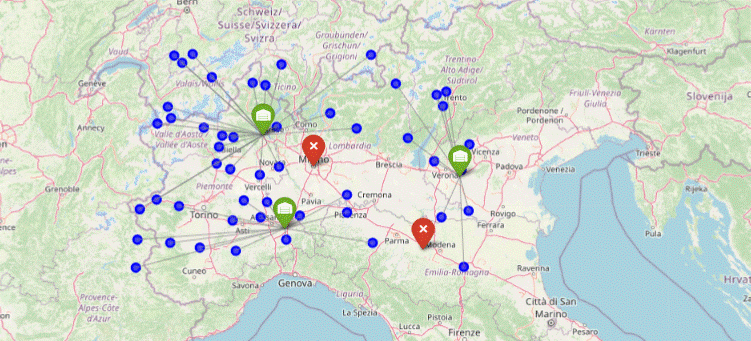